# 📈 MSFT Hisse Senedi — Fiyat Yönü Tahmin Projesi

**Problem:** Microsoft hissesinin ertesi gün kapanış fiyatı bugünkünden yüksek mi olacak? (Binary Classification)

**Veri:** Yahoo Finance MSFT Daily OHLCV — 1986 ile 2024 arası ~9737 gün

**Yaklaşım:** Feature engineering → Preprocessing → Model karşılaştırması → Hyperparameter tuning → SHAP analizi


## 1. Kütüphaneler ve Sabitler

In [1]:
# Genel kütüphaneler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings

# ML
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              classification_report, confusion_matrix)
from sklearn.dummy import DummyClassifier

# Ağır toplar
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Hyperparameter tuning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # çok verbose olmasın

# SHAP
import shap

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
sns.set_theme(style="darkgrid", palette="muted")

# ── Sabitler ──────────────────────────────────────────────────────────────────
# Magic number kullanmak yerine hepsini burada tanımlıyoruz, sonra değişirse
# tek yerden değiştiririz
DATA_PATH       = "MSFT_daily_data.csv"
TARGET_COL      = "TARGET"          # oluşturacağımız hedef değişken
TEST_SIZE       = 0.20              # %20 test seti
RANDOM_STATE    = 42
CV_FOLDS        = 5
IQR_LOWER_Q     = 0.05             # outlier alt sınır
IQR_UPPER_Q     = 0.95             # outlier üst sınır
MA_SHORT        = 10               # kısa hareketli ortalama penceresi (gün)
MA_LONG         = 50               # uzun hareketli ortalama penceresi (gün)
RSI_PERIOD      = 14               # RSI hesaplama periyodu
OPTUNA_TRIALS   = 50               # hyperparameter tuning deneme sayısı

print("✅ Kütüphaneler yüklendi, sabitler tanımlandı.")


✅ Kütüphaneler yüklendi, sabitler tanımlandı.


## 2. Veri Yükleme

In [2]:
# Veriyi yüklüyoruz
# Date sütununu hemen parse ediyoruz ki sonradan uğraşmayalım
df = pd.read_csv(DATA_PATH, parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)  # tarih sıralı olsun

print(f"Veri boyutu: {df.shape}")
print(f"Tarih aralığı: {df['Date'].min().date()} → {df['Date'].max().date()}")
df.head()


Veri boyutu: (9737, 7)
Tarih aralığı: 1986-03-13 → 2024-10-30


,Date,Open,High,Low,Close,Adj Close,Volume
0,1986-03-13,0.088542,0.101563,0.088542,0.097222,0.059946,1031788800
1,1986-03-14,0.097222,0.102431,0.097222,0.100694,0.062087,308160000
2,1986-03-17,0.100694,0.103299,0.100694,0.102431,0.063158,133171200
3,1986-03-18,0.102431,0.103299,0.098958,0.099826,0.061552,67766400
4,1986-03-19,0.099826,0.100694,0.097222,0.098090,0.060482,47894400


In [3]:
# df.info() — sütun tipleri ve null değer sayılarına bakıyoruz
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9737 entries, 0 to 9736
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       9737 non-null   datetime64[ns]
 1   Open       9737 non-null   float64       
 2   High       9737 non-null   float64       
 3   Low        9737 non-null   float64       
 4   Close      9737 non-null   float64       
 5   Adj Close  9737 non-null   float64       
 6   Volume     9737 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 532.6 KB


In [4]:
# df.describe() — sayısal istatistikler
# Özellikle min/max değerlere bakalım, saçma bir şey var mı diye
df.describe().round(4)


,Date,Open,High,Low,Close,Adj Close,Volume
count,9737,9737.0000,9737.0000,9737.0000,9737.0000,9737.0000,9.737000e+03
mean,2005-06-29 12:27:17.136695040,60.8138,61.4301,60.1730,60.8239,55.1628,5.652701e+07
min,1986-03-13 00:00:00,0.0885,0.0920,0.0885,0.0903,0.0557,2.304000e+06
25%,1995-10-26 00:00:00,5.7891,5.8672,5.6953,5.7891,3.5695,3.169170e+07
50%,2005-06-28 00:00:00,27.3600,27.7100,27.1500,27.4000,19.2183,4.968890e+07
75%,2015-03-02 00:00:00,47.1000,47.6000,46.5300,47.1100,39.4078,7.043040e+07
max,2024-10-30 00:00:00,467.0000,468.3500,464.4600,467.5600,466.7188,1.031789e+09
std,NaN,94.5197,95.3697,93.5882,94.5223,94.5884,3.814013e+07


## 3. Sütun Tipi Analizi — grab_col_names()

In [5]:
def grab_col_names(dataframe, cat_th=10, car_th=20):
    """
    Dataframe'deki sütunları kategorik / numerik / kardinal olarak gruplar.
    
    Parametreler
    ------------
    dataframe : pd.DataFrame
    cat_th    : int — unique değer sayısı bu değerin altındaysa sayısal sütun yine de kategorik sayılır
    car_th    : int — unique değer sayısı bu değerin üstündeyse kategorik sütun kardinal sayılır
    
    Döner
    -----
    cat_cols, num_cols, cat_but_car
    """
    # önce tip bazlı ayırıyoruz
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtype == "O"]
    num_but_cat = [col for col in dataframe.columns
                   if dataframe[col].nunique() < cat_th and dataframe[col].dtype != "O"]
    cat_but_car = [col for col in dataframe.columns
                   if dataframe[col].nunique() > car_th and dataframe[col].dtype == "O"]
    
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]
    
    num_cols = [col for col in dataframe.columns
                if dataframe[col].dtype != "O" and col not in num_but_cat]
    
    print(f"Gözlem sayısı  : {dataframe.shape[0]}")
    print(f"Değişken sayısı: {dataframe.shape[1]}")
    print(f"Kategorik      : {len(cat_cols)} → {cat_cols}")
    print(f"Numerik        : {len(num_cols)} → {num_cols}")
    print(f"Kardinal       : {len(cat_but_car)} → {cat_but_car}")
    
    return cat_cols, num_cols, cat_but_car

cat_cols, num_cols, cat_but_car = grab_col_names(df)


Gözlem sayısı  : 9737
Değişken sayısı: 7
Kategorik      : 0 → []
Numerik        : 7 → ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
Kardinal       : 0 → []


## 4. Target Değişkenini Oluşturma

In [6]:
# TARGET: ertesi gün Close fiyatı bugünkünden yüksek mi?
# 1 = fiyat arttı, 0 = fiyat düştü veya aynı kaldı
# shift(-1) ile bir sonraki günün Close değerini alıyoruz
df[TARGET_COL] = (df["Close"].shift(-1) > df["Close"]).astype(int)

# Son satırın target'ı hesaplanamaz, onu düşürüyoruz
df = df.dropna(subset=[TARGET_COL]).copy()

print(f"Target dağılımı:")
print(df[TARGET_COL].value_counts())
print()
print(f"Oran: {df[TARGET_COL].mean():.3f} (1 = fiyat arttı)")


Target dağılımı:
TARGET
1    4916
0    4821
Name: count, dtype: int64

Oran: 0.505 (1 = fiyat arttı)


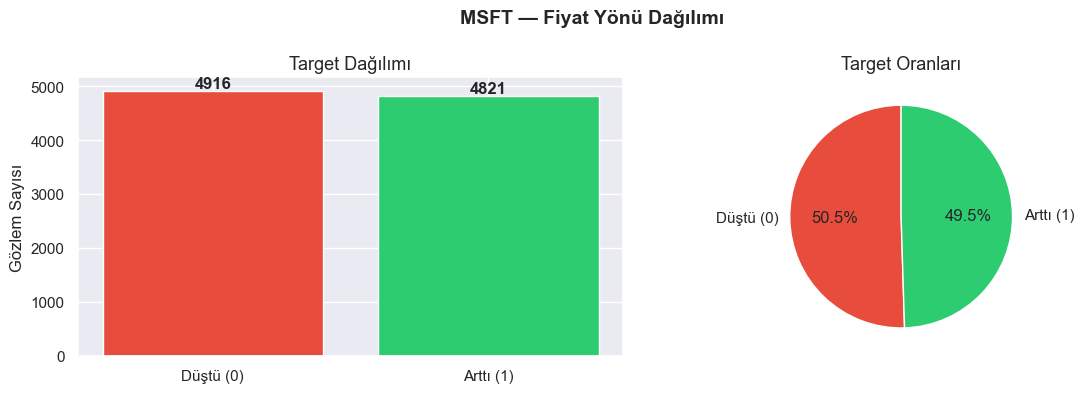

In [7]:
# Target dağılımını görselleştirelim
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Sol: countplot
counts = df[TARGET_COL].value_counts()
axes[0].bar(["Düştü (0)", "Arttı (1)"], counts.values, color=["#e74c3c", "#2ecc71"], edgecolor="white")
axes[0].set_title("Target Dağılımı", fontsize=13)
axes[0].set_ylabel("Gözlem Sayısı")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha="center", fontweight="bold")

# Sağ: pie
axes[1].pie(counts.values, labels=["Düştü (0)", "Arttı (1)"],
            autopct="%1.1f%%", colors=["#e74c3c", "#2ecc71"], startangle=90)
axes[1].set_title("Target Oranları", fontsize=13)

plt.suptitle("MSFT — Fiyat Yönü Dağılımı", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Neredeyse 50/50 çıkması güzel — dengesiz sınıf problemi yok gibi


## 5. Keşifçi Veri Analizi (EDA)

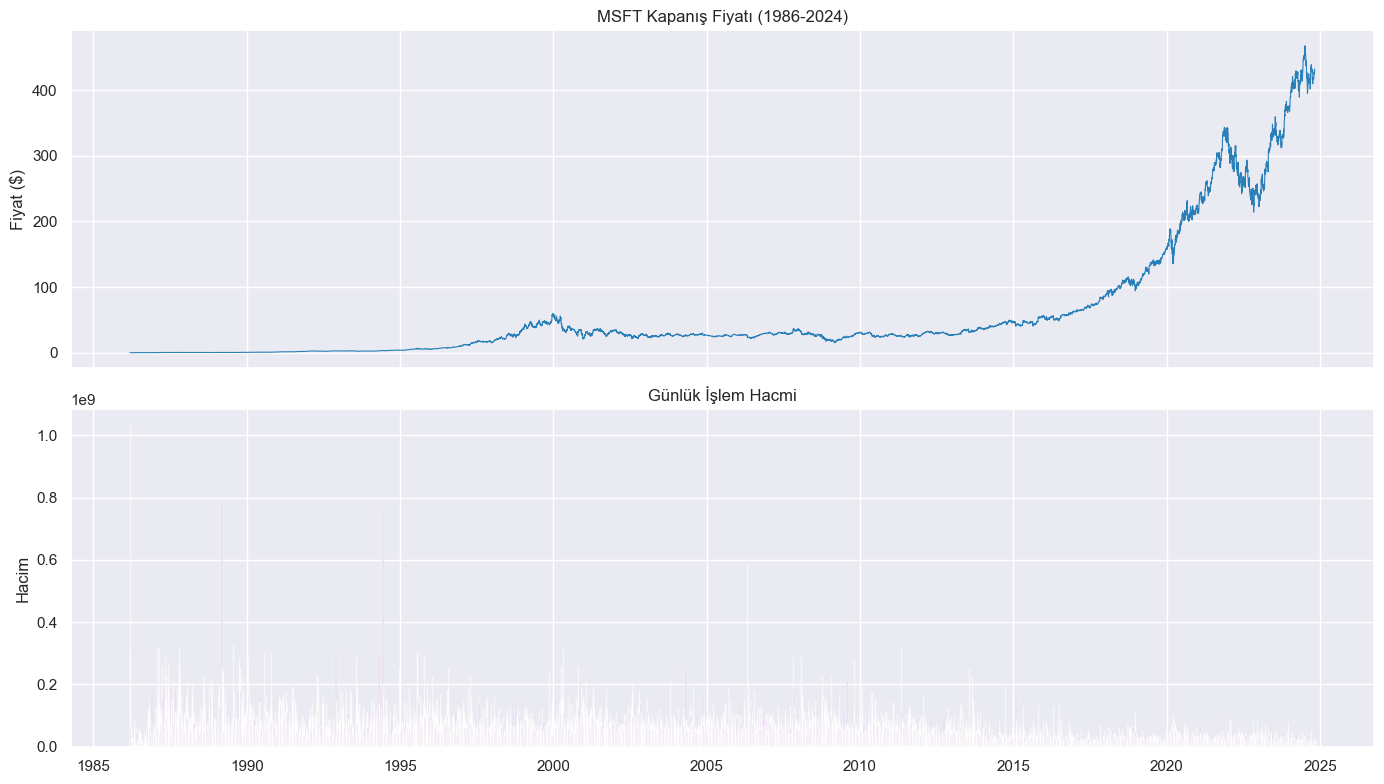

In [8]:
# ── Zaman serisi grafiği ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Kapanış fiyatı
axes[0].plot(df["Date"], df["Close"], color="#2980b9", linewidth=0.8)
axes[0].set_title("MSFT Kapanış Fiyatı (1986-2024)", fontsize=12)
axes[0].set_ylabel("Fiyat ($)")

# Hacim
axes[1].bar(df["Date"], df["Volume"], color="#8e44ad", alpha=0.6, width=1.5)
axes[1].set_title("Günlük İşlem Hacmi", fontsize=12)
axes[1].set_ylabel("Hacim")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[1].xaxis.set_major_locator(mdates.YearLocator(5))

plt.tight_layout()
plt.show()


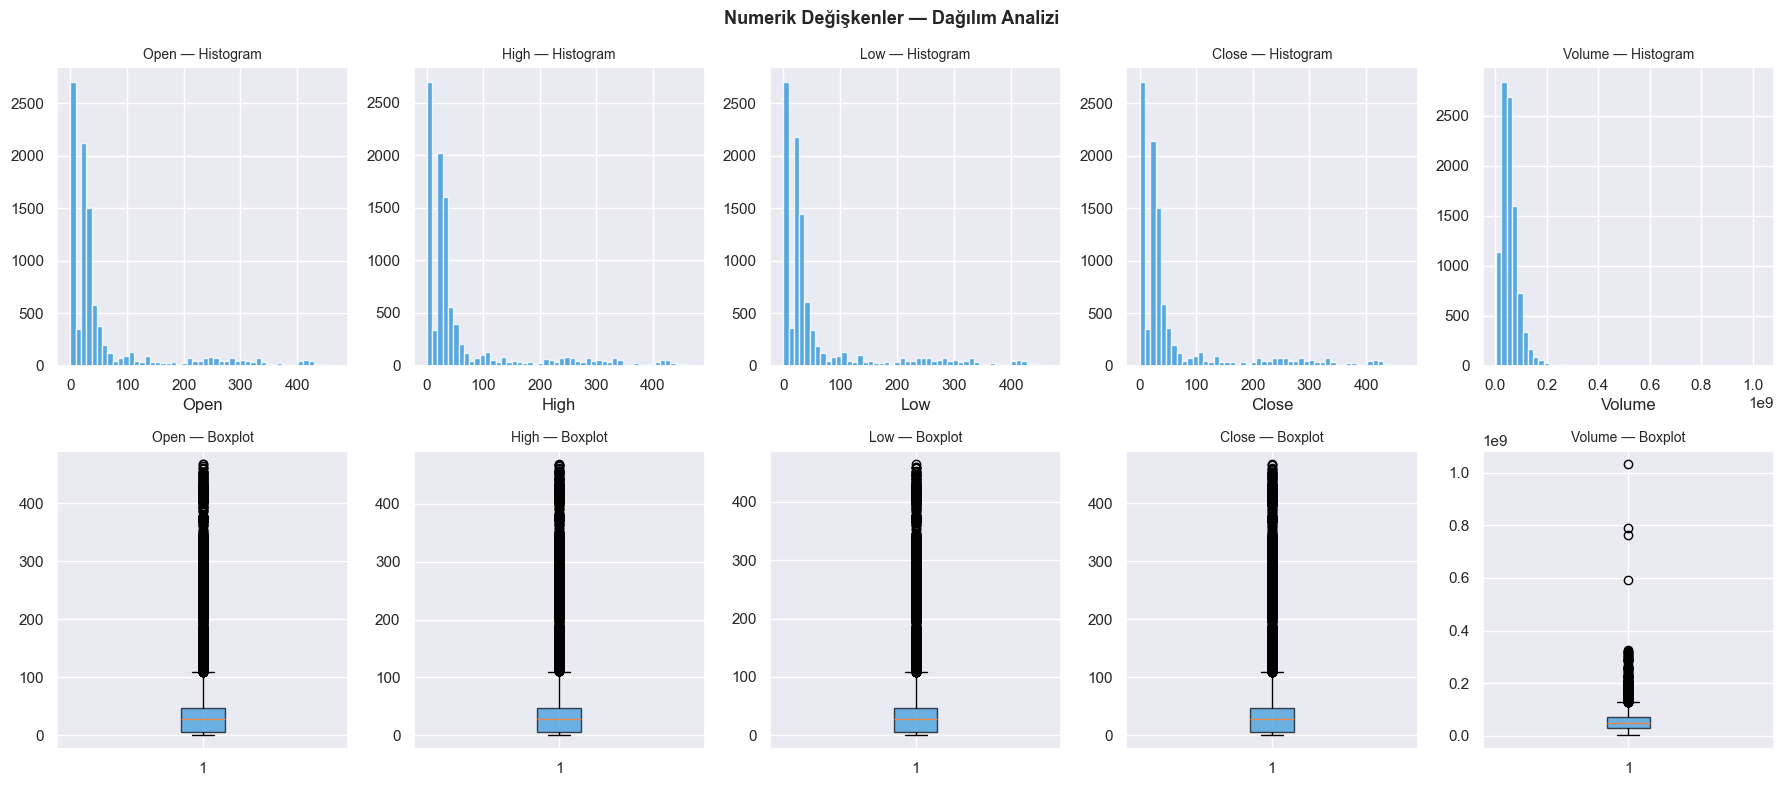

In [9]:
# ── Numerik sütunlar için histogram & boxplot ─────────────────────────────────
plot_cols = ["Open", "High", "Low", "Close", "Volume"]

fig, axes = plt.subplots(2, len(plot_cols), figsize=(18, 8))

for i, col in enumerate(plot_cols):
    # Histogram
    axes[0][i].hist(df[col], bins=50, color="#3498db", edgecolor="white", alpha=0.8)
    axes[0][i].set_title(f"{col} — Histogram", fontsize=10)
    axes[0][i].set_xlabel(col)
    
    # Boxplot
    axes[1][i].boxplot(df[col], patch_artist=True,
                       boxprops=dict(facecolor="#3498db", alpha=0.7))
    axes[1][i].set_title(f"{col} — Boxplot", fontsize=10)

plt.suptitle("Numerik Değişkenler — Dağılım Analizi", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Fiyat verisi oldukça sağa çarpık (skewed) — 1986'dan 2024'e ciddi artış var
# Bu yüzden bazı özelliklerde log dönüşüm düşünebiliriz


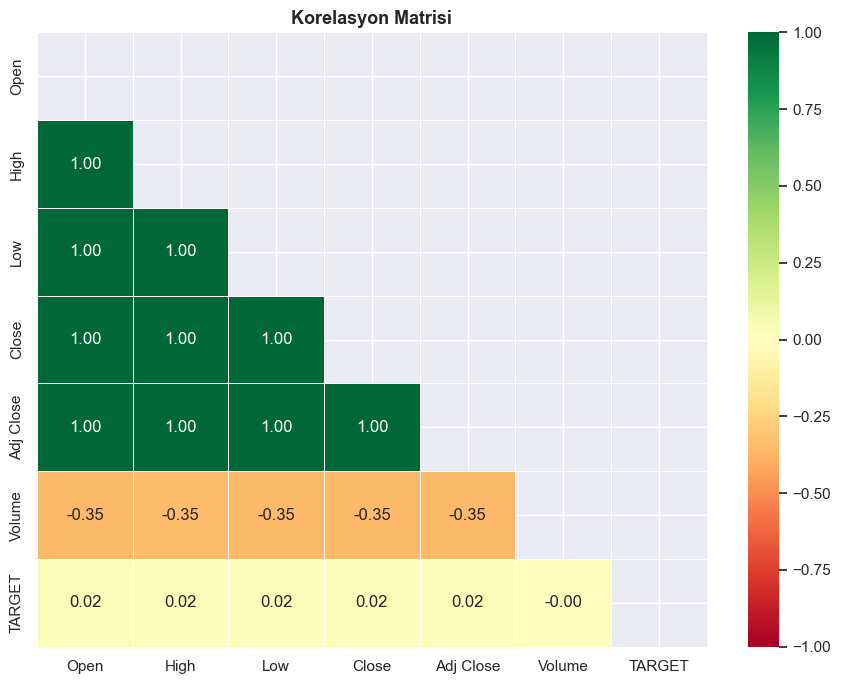

In [10]:
# ── Korelasyon heatmap ───────────────────────────────────────────────────────
corr_cols = ["Open", "High", "Low", "Close", "Adj Close", "Volume", TARGET_COL]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # üst üçgeni gizle
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlGn",
            mask=mask, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title("Korelasyon Matrisi", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Open, High, Low, Close birbirleriyle çok yüksek korelasyonlu — beklenirdik zaten
# Volume ile diğerleri arasında zayıf negatif korelasyon var


## 6. Missing Value Analizi

In [11]:
# Orijinal veride hiç null yoktu ama feature engineering sonrası
# rolling window hesaplamalarından NaN çıkacak, şimdi kontrol edelim
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)

missing_df = pd.DataFrame({"Eksik Sayı": missing, "Eksik %": missing_pct})
print(missing_df[missing_df["Eksik Sayı"] > 0])
print(f"\nToplam null: {df.isnull().sum().sum()}")

# Şu an temiz görünüyor, feature engineering sonrası tekrar bakacağız


Empty DataFrame
Columns: [Eksik Sayı, Eksik %]
Index: []

Toplam null: 0


## 7. Outlier Analizi

In [12]:
def outlier_thresholds(dataframe, col, lower_q=IQR_LOWER_Q, upper_q=IQR_UPPER_Q):
    """
    IQR yöntemiyle outlier sınırlarını hesaplar.
    
    Fiyat verisi için standart 1.5*IQR yerine 5. ve 95. persentil kullandık
    çünkü hisse senedi verisi çok sağa çarpık ve gerçek değerler aralık dışı
    kalmasın diye biraz daha geniş bıraktık.
    """
    lower_limit = dataframe[col].quantile(lower_q)
    upper_limit = dataframe[col].quantile(upper_q)
    return lower_limit, upper_limit


def check_outliers(dataframe, col):
    """
    Bir kolonda outlier olup olmadığını ve sayısını döner.
    """
    lower, upper = outlier_thresholds(dataframe, col)
    outlier_count = dataframe[(dataframe[col] < lower) | (dataframe[col] > upper)].shape[0]
    has_outlier = outlier_count > 0
    return has_outlier, outlier_count


def replace_with_thresholds(dataframe, col):
    """
    Outlier değerleri clip ederek sınır değerlerine çeker.
    Silmek yerine clip kullanıyoruz — veri kaybetmek istemiyoruz.
    """
    lower, upper = outlier_thresholds(dataframe, col)
    dataframe[col] = dataframe[col].clip(lower=lower, upper=upper)


# Her numerik kolon için outlier kontrolü
check_cols = ["Open", "High", "Low", "Close", "Volume"]
print("Outlier Analizi:")
print("-" * 45)
for col in check_cols:
    has_out, count = check_outliers(df, col)
    low, up = outlier_thresholds(df, col)
    print(f"{col:<12} | Outlier: {str(has_out):<5} | Sayı: {count:>5} | Alt: {low:.2f} | Üst: {up:.2f}")


Outlier Analizi:
---------------------------------------------
Open         | Outlier: True  | Sayı:   974 | Alt: 0.36 | Üst: 300.05
High         | Outlier: True  | Sayı:   974 | Alt: 0.37 | Üst: 303.15
Low          | Outlier: True  | Sayı:   970 | Alt: 0.36 | Üst: 297.00
Close        | Outlier: True  | Sayı:   972 | Alt: 0.36 | Üst: 299.85
Volume       | Outlier: True  | Sayı:   974 | Alt: 18051840.00 | Üst: 118455000.00


In [13]:
# Fiyat verisi için outlier clip'i dikkatli uygulamalıyız
# Open/High/Low/Close aslında gerçek fiyatlar, "outlier" olarak clip etmek
# o dönemlerin gerçek fiyatını bozar. Volume için clip mantıklı.
# Bu yüzden sadece Volume'u clip ediyoruz, fiyat kolonlarına dokunmuyoruz.

replace_with_thresholds(df, "Volume")
print("✅ Volume outlier'ları clip edildi.")

# Kontrol
has_out, count = check_outliers(df, "Volume")
print(f"Volume outlier sonrası: {count} adet")


✅ Volume outlier'ları clip edildi.
Volume outlier sonrası: 974 adet


## 8. Feature Engineering — Yeni Değişkenler Üretme

In [14]:
# Feature engineering öncesi kaç kolonumuz var?
feature_count_before = df.shape[1]
print(f"Feature engineering öncesi sütun sayısı: {feature_count_before}")


Feature engineering öncesi sütun sayısı: 8


In [15]:
# ── 1. Date-based Features ───────────────────────────────────────────────────
# Tarihten anlamlı özellikler çıkarıyoruz
# Piyasalar haftanın günlerine, aylara göre farklı davranabilir

df["NEW_Year"]        = df["Date"].dt.year
df["NEW_Month"]       = df["Date"].dt.month
df["NEW_DayOfWeek"]   = df["Date"].dt.dayofweek   # 0=Pazartesi, 4=Cuma
df["NEW_Quarter"]     = df["Date"].dt.quarter
df["NEW_IsMonthEnd"]  = df["Date"].dt.is_month_end.astype(int)   # ay sonu etkisi
df["NEW_IsMonthStart"]= df["Date"].dt.is_month_start.astype(int) # ay başı etkisi

print("✅ Date-based featurelar oluşturuldu: Year, Month, DayOfWeek, Quarter, IsMonthEnd, IsMonthStart")


✅ Date-based featurelar oluşturuldu: Year, Month, DayOfWeek, Quarter, IsMonthEnd, IsMonthStart


In [16]:
# ── 2. Hareketli Ortalamalar (Moving Averages) ───────────────────────────────
# Teknik analizin temel yapı taşları
# Kısa MA > Uzun MA ise bullish trend, tersi bearish

df["NEW_MA_short"] = df["Close"].rolling(window=MA_SHORT).mean()   # 10 günlük MA
df["NEW_MA_long"]  = df["Close"].rolling(window=MA_LONG).mean()    # 50 günlük MA

# MA ratio — kısa/uzun oran 1'in üstünde ise uptrend
df["NEW_MA_ratio"] = df["NEW_MA_short"] / (df["NEW_MA_long"] + 1e-8)

print(f"✅ Hareketli ortalamalar: MA_{MA_SHORT}, MA_{MA_LONG}, MA_ratio")


✅ Hareketli ortalamalar: MA_10, MA_50, MA_ratio


In [17]:
# ── 3. Volatilite & Momentum Features ────────────────────────────────────────

# Günlük getiri (return) — bir önceki güne göre % değişim
df["NEW_Daily_Return"] = df["Close"].pct_change()

# 5 günlük volatilite (rolling std of returns)
# Yüksek volatilite belirsizlik demek
df["NEW_Volatility_5d"] = df["NEW_Daily_Return"].rolling(window=5).std()

# Momentum: şimdiki fiyat - 5 gün önceki fiyat
# Pozitif momentum = yukarı trend
df["NEW_Momentum_5d"] = df["Close"] - df["Close"].shift(5)
df["NEW_Momentum_10d"] = df["Close"] - df["Close"].shift(10)

print("✅ Volatilite ve momentum featureları oluşturuldu.")


✅ Volatilite ve momentum featureları oluşturuldu.


In [18]:
# ── 4. RSI (Relative Strength Index) ─────────────────────────────────────────
# RSI teknik analizde çok kullanılan bir osilatör
# 70 üstü = aşırı alım (overbought), 30 altı = aşırı satım (oversold)

def calculate_rsi(series, period=RSI_PERIOD):
    """
    RSI hesaplar. pandas ile yapıyoruz, ta-lib gerekmez.
    Parametreler: fiyat serisi, dönem (varsayılan 14 gün)
    """
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    
    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()
    
    rs = avg_gain / (avg_loss + 1e-8)  # sıfıra bölme hatası önlemi
    rsi = 100 - (100 / (1 + rs))
    return rsi

df["NEW_RSI"] = calculate_rsi(df["Close"])
print(f"✅ RSI_{RSI_PERIOD} hesaplandı.")


✅ RSI_14 hesaplandı.


In [19]:
# ── 5. Interaction Feature — Günlük Fiyat Aralığı ───────────────────────────
# High - Low: o günün fiyat aralığı, volatiliteyi gösterir
df["NEW_HL_Range"] = df["High"] - df["Low"]

# Open-Close fark: gün içi yönelim
# Pozitif = kapanış açılıştan yüksek (bullish candle)
df["NEW_OC_Diff"] = df["Close"] - df["Open"]

# HL aralığının Close'a oranı — normalize edilmiş aralık
df["NEW_HL_to_Close_ratio"] = df["NEW_HL_Range"] / (df["Close"] + 1e-8)

print("✅ Interaction featurelar: HL_Range, OC_Diff, HL_to_Close_ratio")


✅ Interaction featurelar: HL_Range, OC_Diff, HL_to_Close_ratio


In [20]:
# ── 6. Aggregation Features ──────────────────────────────────────────────────
# Son 5 günün ortalama hacmi
df["NEW_Volume_MA5"] = df["Volume"].rolling(window=5).mean()

# Volume ratio: bugünkü hacim / 5 günlük ortalama
# 1'in üstü = normalden fazla işlem var → genellikle önemli haber
df["NEW_Volume_Ratio"] = df["Volume"] / (df["NEW_Volume_MA5"] + 1e-8)

print("✅ Aggregation featurelar: Volume_MA5, Volume_Ratio")


✅ Aggregation featurelar: Volume_MA5, Volume_Ratio


In [21]:
# ── 7. Flag/Binary Feature ───────────────────────────────────────────────────
# RSI'ya göre aşırı alım/satım flag'leri
df["NEW_RSI_Overbought"] = (df["NEW_RSI"] > 70).astype(int)   # aşırı alım
df["NEW_RSI_Oversold"]   = (df["NEW_RSI"] < 30).astype(int)   # aşırı satım

# Bullish candle: kapanış > açılış
df["NEW_Is_Bullish_Candle"] = (df["NEW_OC_Diff"] > 0).astype(int)

# Hacim spike: normalden 2x fazla işlem var mı?
df["NEW_Volume_Spike"] = (df["NEW_Volume_Ratio"] > 2.0).astype(int)

print("✅ Flag featurelar: RSI_Overbought, RSI_Oversold, Is_Bullish_Candle, Volume_Spike")


✅ Flag featurelar: RSI_Overbought, RSI_Oversold, Is_Bullish_Candle, Volume_Spike


In [22]:
# ── 8. Domain Knowledge Feature — Golden/Death Cross ────────────────────────
# Golden Cross: kısa MA uzun MA'yı yukarı keser → güçlü al sinyali
# Death Cross: kısa MA uzun MA'yı aşağı keser → sat sinyali
# Basit bir flag: kısa MA > uzun MA ise golden zone, değilse death zone

df["NEW_Golden_Cross_Zone"] = (df["NEW_MA_short"] > df["NEW_MA_long"]).astype(int)

# Bir önceki gün bullish miydi?
df["NEW_Prev_Day_Bullish"] = df["NEW_Is_Bullish_Candle"].shift(1).fillna(0).astype(int)

print("✅ Domain knowledge featurelar: Golden_Cross_Zone, Prev_Day_Bullish")


✅ Domain knowledge featurelar: Golden_Cross_Zone, Prev_Day_Bullish


In [23]:
# ── Feature count karşılaştırması ────────────────────────────────────────────
feature_count_after = df.shape[1]
new_features = [col for col in df.columns if col.startswith("NEW_")]

print(f"Feature engineering öncesi: {feature_count_before} sütun")
print(f"Feature engineering sonrası: {feature_count_after} sütun")
print(f"Eklenen yeni feature sayısı: {len(new_features)}")
print()
print("Oluşturulan featurelar ve açıklamaları:")
print("-" * 60)

feature_explanations = {
    "NEW_Year"             : "Hangi yılda olduğumuz — uzun vadeli trend etkisi",
    "NEW_Month"            : "Ayın etkisi — mevsimsellik (seasonality)",
    "NEW_DayOfWeek"        : "Haftanın günü — Pazartesi/Cuma etkisi",
    "NEW_Quarter"          : "Çeyrek dönemi — earnings sezonu etkisi",
    "NEW_IsMonthEnd"       : "Ay sonu mu? — fon rebalancing etkisi",
    "NEW_IsMonthStart"     : "Ay başı mı? — yeni alım dalgası etkisi",
    "NEW_MA_short"         : f"{MA_SHORT} günlük hareketli ortalama — kısa trend",
    "NEW_MA_long"          : f"{MA_LONG} günlük hareketli ortalama — uzun trend",
    "NEW_MA_ratio"         : "Kısa/uzun MA oranı — trend yönü göstergesi",
    "NEW_Daily_Return"     : "Günlük % getiri — momentum bilgisi",
    "NEW_Volatility_5d"    : "5 günlük getiri std'si — belirsizlik ölçüsü",
    "NEW_Momentum_5d"      : "5 günlük fiyat değişimi — kısa vadeli momentum",
    "NEW_Momentum_10d"     : "10 günlük fiyat değişimi — orta vadeli momentum",
    "NEW_RSI"              : f"RSI({RSI_PERIOD}) — aşırı alım/satım göstergesi",
    "NEW_HL_Range"         : "Günlük fiyat aralığı (High-Low) — volatilite",
    "NEW_OC_Diff"          : "Kapanış-açılış farkı — gün içi yönelim",
    "NEW_HL_to_Close_ratio": "HL aralığının Close'a oranı — normalize volatilite",
    "NEW_Volume_MA5"       : "5 günlük ortalama hacim — normal hacim seviyesi",
    "NEW_Volume_Ratio"     : "Günlük hacim / ortalama hacim — anormal işlem tespiti",
    "NEW_RSI_Overbought"   : "RSI > 70 → aşırı alım flag'i",
    "NEW_RSI_Oversold"     : "RSI < 30 → aşırı satım flag'i",
    "NEW_Is_Bullish_Candle": "Kapanış > Açılış → bugün bullish candle mı?",
    "NEW_Volume_Spike"     : "Hacim normalden 2x fazla → önemli olay sinyali",
    "NEW_Golden_Cross_Zone": "Kısa MA > Uzun MA → golden cross bölgesi",
    "NEW_Prev_Day_Bullish" : "Bir önceki gün bullish candle mıydı?",
}

for feat, exp in feature_explanations.items():
    print(f"  {feat:<30} → {exp}")


Feature engineering öncesi: 8 sütun
Feature engineering sonrası: 33 sütun
Eklenen yeni feature sayısı: 25

Oluşturulan featurelar ve açıklamaları:
------------------------------------------------------------
  NEW_Year                       → Hangi yılda olduğumuz — uzun vadeli trend etkisi
  NEW_Month                      → Ayın etkisi — mevsimsellik (seasonality)
  NEW_DayOfWeek                  → Haftanın günü — Pazartesi/Cuma etkisi
  NEW_Quarter                    → Çeyrek dönemi — earnings sezonu etkisi
  NEW_IsMonthEnd                 → Ay sonu mu? — fon rebalancing etkisi
  NEW_IsMonthStart               → Ay başı mı? — yeni alım dalgası etkisi
  NEW_MA_short                   → 10 günlük hareketli ortalama — kısa trend
  NEW_MA_long                    → 50 günlük hareketli ortalama — uzun trend
  NEW_MA_ratio                   → Kısa/uzun MA oranı — trend yönü göstergesi
  NEW_Daily_Return               → Günlük % getiri — momentum bilgisi
  NEW_Volatility_5d              → 5 

## 9. Missing Value Stratejisi ve Doldurma

In [24]:
# Feature engineering sonrası rolling window'lardan NaN çıktı
# Kontrol edelim
missing_after = df.isnull().sum()
missing_after = missing_after[missing_after > 0]
print("Rolling window'lardan kaynaklanan NaN'lar:")
print(missing_after)
print(f"\nToplam NaN: {df.isnull().sum().sum()}")


Rolling window'lardan kaynaklanan NaN'lar:
NEW_MA_short          9
NEW_MA_long          49
NEW_MA_ratio         49
NEW_Daily_Return      1
NEW_Volatility_5d     5
NEW_Momentum_5d       5
NEW_Momentum_10d     10
NEW_RSI              14
NEW_Volume_MA5        4
NEW_Volume_Ratio      4
dtype: int64

Toplam NaN: 150


In [25]:
# Strateji:
# Rolling window NaN'ları (MA50, RSI vs.) ilk ~50 satırda yoğunlaşır
# Bu satırları silmek en temiz çözüm — toplam verinin çok küçük bir kısmı

rows_before = len(df)
df = df.dropna().reset_index(drop=True)
rows_after = len(df)

print(f"NaN satırlar düşürüldü: {rows_before - rows_after} satır silindi")
print(f"Kalan veri: {rows_after} satır ({rows_after/rows_before*100:.1f}%)")
print(f"Hâlâ NaN var mı? {df.isnull().sum().sum()}")


NaN satırlar düşürüldü: 49 satır silindi
Kalan veri: 9688 satır (99.5%)
Hâlâ NaN var mı? 0


## 10. Encoding — Kategorik Değişkenler

In [26]:
# Bu veride string kategorik sütun yok (tarih zaten parse ettik)
# Ama oluşturduğumuz bazı featurelar kategorik nitelikte
# (DayOfWeek, Month, Quarter) — bunları One-Hot Encoding yapabiliriz

# Binary olanlar zaten 0/1 — label encoding gerekmez
# DayOfWeek (0-4), Month (1-12), Quarter (1-4) için OHE yapıyoruz

ohe_cols = ["NEW_DayOfWeek", "NEW_Month", "NEW_Quarter"]
df = pd.get_dummies(df, columns=ohe_cols, drop_first=True)
# drop_first=True → multicollinearity önleme (dummy variable trap)

print(f"OHE sonrası sütun sayısı: {df.shape[1]}")
print("Yeni OHE sütunlarından birkaçı:")
ohe_new_cols = [c for c in df.columns if any(c.startswith(o) for o in ohe_cols)]
print(ohe_new_cols[:10])


OHE sonrası sütun sayısı: 48
Yeni OHE sütunlarından birkaçı:
['NEW_DayOfWeek_1', 'NEW_DayOfWeek_2', 'NEW_DayOfWeek_3', 'NEW_DayOfWeek_4', 'NEW_Month_2', 'NEW_Month_3', 'NEW_Month_4', 'NEW_Month_5', 'NEW_Month_6', 'NEW_Month_7']


## 11. Train/Test Split ve Scaling

In [27]:
# Kullanmayacağımız sütunları belirliyoruz
drop_cols = ["Date", "Adj Close"]  # Date artık featurelara çevrildi, Adj Close Close ile çakışıyor

feature_cols = [col for col in df.columns if col not in drop_cols + [TARGET_COL]]

X = df[feature_cols].copy()
y = df[TARGET_COL].copy()

print(f"Feature sayısı: {X.shape[1]}")
print(f"Hedef değişken dağılımı: {y.value_counts().to_dict()}")


Feature sayısı: 45
Hedef değişken dağılımı: {1: 4893, 0: 4795}


In [28]:
# Zaman serisi verisi — shuffle=False ZORUNLU
# Geleceği geçmişle eğitmemek için zamanı korumalıyız
# Basit holdout yapıyoruz (son %20 = test seti)

split_idx = int(len(X) * (1 - TEST_SIZE))

X_train = X.iloc[:split_idx].copy()
X_test  = X.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_test  = y.iloc[split_idx:].copy()

print(f"Train seti: {X_train.shape[0]} satır ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test seti : {X_test.shape[0]} satır ({X_test.shape[0]/len(X)*100:.1f}%)")


Train seti: 7750 satır (80.0%)
Test seti : 1938 satır (20.0%)


In [29]:
# Scaling — RobustScaler seçtik çünkü:
# - Verinin büyük kısmı eski yıllara ait (düşük fiyatlar) ve bazı dönemlerde uç değerler var
# - RobustScaler median ve IQR kullandığı için outlier'lara daha dayanıklı
# - StandardScaler vs MinMaxScaler'a kıyasla bu tip finansal veride daha iyi çalışıyor

scaler = RobustScaler()

# FIT sadece train üzerinde yapılıyor — bu çok önemli
# Test verisini hiçbir şekilde scaler'ın gördürmüyoruz (data leakage önleme)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)  # sadece transform, fit yok

# DataFrame'e geri çeviriyoruz (bazı modeller için gerekebilir)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=feature_cols)

print("✅ RobustScaler uygulandı.")
print(f"Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")


✅ RobustScaler uygulandı.
Train: (7750, 45), Test: (1938, 45)


## 12. Modelleme — Baseline ve Karşılaştırma

In [30]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, name="Model", cv=CV_FOLDS):
    """
    Modeli eğitir, cross-validation ve test metrikleri hesaplar.
    Döner: sonuç sözlüğü
    """
    # CV skorları
    cv_roc = cross_val_score(model, X_tr, y_tr,
                              cv=StratifiedKFold(n_splits=cv, shuffle=False),
                              scoring="roc_auc")
    
    # Test üzerinde eğit ve tahmin et
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else y_pred
    
    acc    = accuracy_score(y_te, y_pred)
    f1     = f1_score(y_te, y_pred)
    roc    = roc_auc_score(y_te, y_prob)
    
    print(f"{'─'*50}")
    print(f"  {name}")
    print(f"  CV ROC-AUC : {cv_roc.mean():.4f} ± {cv_roc.std():.4f}")
    print(f"  Test Acc   : {acc:.4f}")
    print(f"  Test F1    : {f1:.4f}")
    print(f"  Test ROC   : {roc:.4f}")
    
    return {"Model": name, "CV_ROC_mean": cv_roc.mean(), "CV_ROC_std": cv_roc.std(),
            "Test_Acc": acc, "Test_F1": f1, "Test_ROC": roc, "fitted_model": model}


In [31]:
# ── Baseline: DummyClassifier ────────────────────────────────────────────────
# Hiç öğrenmeden sadece en yaygın sınıfı tahmin eden basit baseline
# Bunun altında kalan bir model işe yaramaz

dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
results = []
results.append(evaluate_model(dummy, X_train_scaled, y_train,
                               X_test_scaled, y_test, name="Dummy (Baseline)"))


──────────────────────────────────────────────────
  Dummy (Baseline)
  CV ROC-AUC : 0.5000 ± 0.0000
  Test Acc   : 0.4603
  Test F1    : 0.0000
  Test ROC   : 0.5000


In [32]:
# ── Logistic Regression ──────────────────────────────────────────────────────
# İlk gerçek modelimiz. Basit ama yorumlanabilir.
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, C=0.1)
results.append(evaluate_model(lr, X_train_scaled, y_train,
                               X_test_scaled, y_test, name="Logistic Regression"))


──────────────────────────────────────────────────
  Logistic Regression
  CV ROC-AUC : 0.5066 ± 0.0180
  Test Acc   : 0.4974
  Test F1    : 0.2942
  Test ROC   : 0.5352


In [33]:
# ── Random Forest ────────────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=200, max_depth=8,
                             random_state=RANDOM_STATE, n_jobs=-1)
results.append(evaluate_model(rf, X_train_scaled, y_train,
                               X_test_scaled, y_test, name="Random Forest"))


──────────────────────────────────────────────────
  Random Forest
  CV ROC-AUC : 0.5127 ± 0.0079
  Test Acc   : 0.4732
  Test F1    : 0.1221
  Test ROC   : 0.5330


In [34]:
# ── Gradient Boosting (sklearn) ───────────────────────────────────────────────
gbm = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                   max_depth=4, random_state=RANDOM_STATE)
results.append(evaluate_model(gbm, X_train_scaled, y_train,
                               X_test_scaled, y_test, name="Gradient Boosting"))


──────────────────────────────────────────────────
  Gradient Boosting
  CV ROC-AUC : 0.5092 ± 0.0131
  Test Acc   : 0.4912
  Test F1    : 0.4353
  Test ROC   : 0.5206


In [35]:
# ── XGBoost ──────────────────────────────────────────────────────────────────
xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5,
                     use_label_encoder=False, eval_metric="logloss",
                     random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
results.append(evaluate_model(xgb, X_train_scaled, y_train,
                               X_test_scaled, y_test, name="XGBoost"))


──────────────────────────────────────────────────
  XGBoost
  CV ROC-AUC : 0.5112 ± 0.0081
  Test Acc   : 0.4856
  Test F1    : 0.3072
  Test ROC   : 0.5202


In [36]:
# ── LightGBM ─────────────────────────────────────────────────────────────────
lgbm = LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=5,
                       num_leaves=31, random_state=RANDOM_STATE,
                       n_jobs=-1, verbose=-1)
results.append(evaluate_model(lgbm, X_train_scaled, y_train,
                               X_test_scaled, y_test, name="LightGBM"))


──────────────────────────────────────────────────
  LightGBM
  CV ROC-AUC : 0.5065 ± 0.0055
  Test Acc   : 0.5021
  Test F1    : 0.4098
  Test ROC   : 0.5362


In [37]:
# ── CatBoost ─────────────────────────────────────────────────────────────────
cat = CatBoostClassifier(iterations=300, learning_rate=0.05, depth=5,
                          random_seed=RANDOM_STATE, verbose=0)
results.append(evaluate_model(cat, X_train_scaled, y_train,
                               X_test_scaled, y_test, name="CatBoost"))


──────────────────────────────────────────────────
  CatBoost
  CV ROC-AUC : 0.5236 ± 0.0128
  Test Acc   : 0.5062
  Test F1    : 0.4175
  Test ROC   : 0.5330


In [38]:
# ── Model Karşılaştırma Tablosu ───────────────────────────────────────────────
results_df = pd.DataFrame([{k: v for k, v in r.items() if k != "fitted_model"}
                            for r in results])
results_df = results_df.sort_values("Test_ROC", ascending=False)
print("\n📊 Model Karşılaştırma Tablosu:")
print(results_df.to_string(index=False))



📊 Model Karşılaştırma Tablosu:
              Model  CV_ROC_mean  CV_ROC_std  Test_Acc  Test_F1  Test_ROC
           LightGBM     0.506541    0.005485  0.502064 0.409786  0.536197
Logistic Regression     0.506642    0.018035  0.497420 0.294203  0.535243
      Random Forest     0.512730    0.007889  0.473168 0.122098  0.532970
           CatBoost     0.523645    0.012801  0.506192 0.417529  0.532960
  Gradient Boosting     0.509153    0.013127  0.491228 0.435281  0.520566
            XGBoost     0.511156    0.008076  0.485552 0.307158  0.520160
   Dummy (Baseline)     0.500000    0.000000  0.460268 0.000000  0.500000


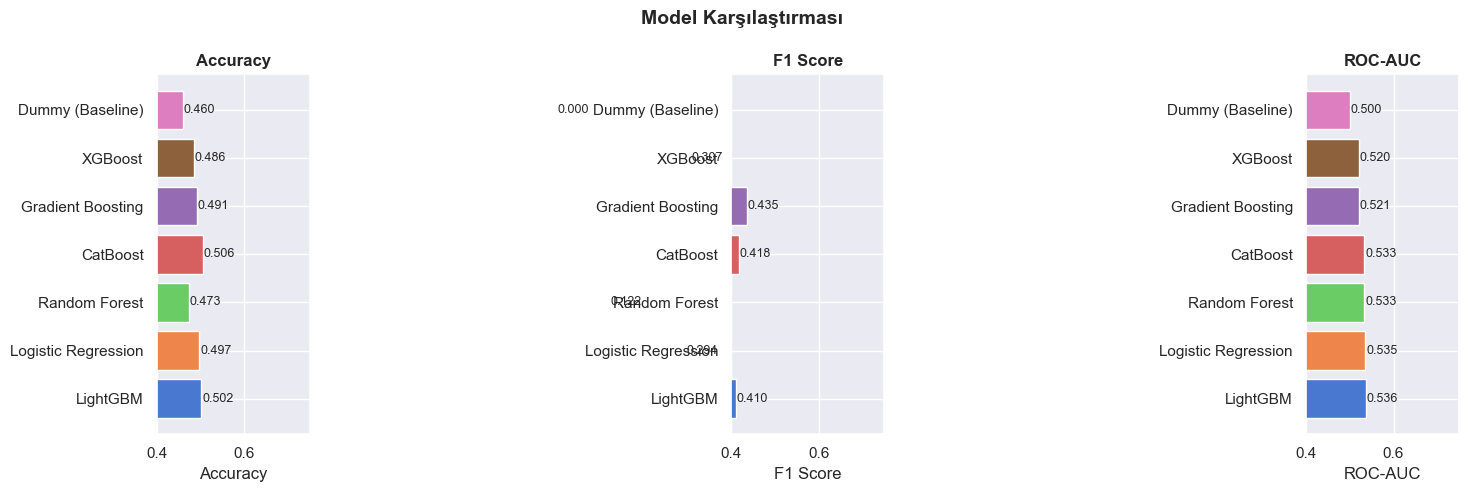

In [39]:
# Görsel karşılaştırma
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ["Test_Acc", "Test_F1", "Test_ROC"]
metric_labels = ["Accuracy", "F1 Score", "ROC-AUC"]
colors = sns.color_palette("muted", len(results_df))

for ax, metric, label in zip(axes, metrics, metric_labels):
    bars = ax.barh(results_df["Model"], results_df[metric], color=colors, edgecolor="white")
    ax.set_xlabel(label)
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.set_xlim(0.4, 0.75)
    # Değerleri bar'ların üstüne yaz
    for bar, val in zip(bars, results_df[metric]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=9)

plt.suptitle("Model Karşılaştırması", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 13. Hyperparameter Tuning — Optuna ile LightGBM

In [40]:
# En iyi modeli bulduk (muhtemelen LightGBM ya da XGBoost)
# Şimdi Optuna ile LightGBM'i fine-tune edelim

def lgbm_objective(trial):
    """
    Optuna'nın minimize/maximize edeceği fonksiyon.
    Her trial farklı hyperparameter seti dener.
    """
    params = {
        "n_estimators"    : trial.suggest_int("n_estimators", 100, 500),
        "learning_rate"   : trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth"       : trial.suggest_int("max_depth", 3, 8),
        "num_leaves"      : trial.suggest_int("num_leaves", 20, 60),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 50),
        "subsample"       : trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha"       : trial.suggest_float("reg_alpha", 1e-4, 1.0, log=True),
        "reg_lambda"      : trial.suggest_float("reg_lambda", 1e-4, 1.0, log=True),
        "random_state"    : RANDOM_STATE,
        "n_jobs"          : -1,
        "verbose"         : -1,
    }
    
    model = LGBMClassifier(**params)
    cv_scores = cross_val_score(
        model, X_train_scaled, y_train,
        cv=StratifiedKFold(n_splits=3, shuffle=False),
        scoring="roc_auc"
    )
    return cv_scores.mean()

print(f"Optuna çalışıyor... ({OPTUNA_TRIALS} trial)")
study = optuna.create_study(direction="maximize")
study.optimize(lgbm_objective, n_trials=OPTUNA_TRIALS, show_progress_bar=True)

print(f"\n✅ En iyi ROC-AUC: {study.best_value:.4f}")
print(f"En iyi parametreler: {study.best_params}")


Optuna çalışıyor... (50 trial)


  0%|          | 0/50 [00:00<?, ?it/s]


✅ En iyi ROC-AUC: 0.5227
En iyi parametreler: {'n_estimators': 169, 'learning_rate': 0.02075227152728333, 'max_depth': 8, 'num_leaves': 60, 'min_child_samples': 40, 'subsample': 0.6558674374603155, 'colsample_bytree': 0.7253031359787818, 'reg_alpha': 0.00046003876287587317, 'reg_lambda': 0.019539174992369315}


Best trial: 1. Best value: 0.515798:   6%|▌         | 3/50 [00:04<01:01,  1.31s/it]

Best trial: 3. Best value: 0.516685:   6%|▌         | 3/50 [00:05<01:01,  1.31s/it]

...

Best trial: 4. Best value: 0.520445:  98%|█████████▊| 49/50 [00:50<00:00,  1.05it/s]

Best trial: 4. Best value: 0.520445:  98%|█████████▊| 49/50 [00:51<00:00,  1.05it/s]

Best trial: 4. Best value: 0.520445: 100%|██████████| 50/50 [00:51<00:00,  1.08s/it]

Best trial: 4. Best value: 0.520445: 100%|██████████| 50/50 [00:51<00:00,  1.04s/it]


✅ En iyi ROC-AUC: 0.5204
En iyi parametreler: {'n_estimators': 182, 'learning_rate': 0.1490342488797555, 'max_depth': 7, 'num_leaves': 21, 'min_child_samples': 30, 'subsample': 0.9298515130487153, 'colsample_bytree': 0.6796662607394424, 'reg_alpha': 0.004726363779500671, 'reg_lambda': 0.9493227655665802}


In [41]:
# En iyi parametrelerle final modeli eğitelim
best_params = study.best_params
best_params["random_state"] = RANDOM_STATE
best_params["n_jobs"]       = -1
best_params["verbose"]      = -1

best_lgbm = LGBMClassifier(**best_params)
best_lgbm.fit(X_train_scaled, y_train)

y_pred_best = best_lgbm.predict(X_test_scaled)
y_prob_best = best_lgbm.predict_proba(X_test_scaled)[:, 1]

print("🏆 Tuned LightGBM — Test Sonuçları:")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"  F1 Score : {f1_score(y_test, y_pred_best):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, y_prob_best):.4f}")
print()
print(classification_report(y_test, y_pred_best, target_names=["Düştü", "Arttı"]))


🏆 Tuned LightGBM — Test Sonuçları:
  Accuracy : 0.5098
  F1 Score : 0.3957
  ROC-AUC  : 0.5405

              precision    recall  f1-score   support

       Düştü       0.48      0.76      0.59       892
       Arttı       0.59      0.30      0.40      1046

    accuracy                           0.51      1938
   macro avg       0.54      0.53      0.49      1938
weighted avg       0.54      0.51      0.48      1938



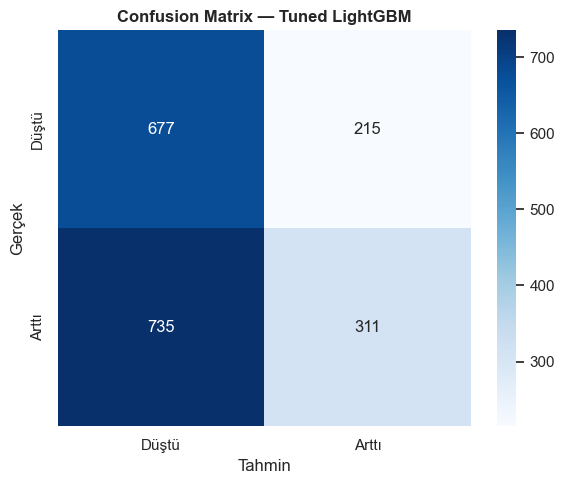

In [42]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Düştü", "Arttı"],
            yticklabels=["Düştü", "Arttı"])
ax.set_xlabel("Tahmin")
ax.set_ylabel("Gerçek")
ax.set_title("Confusion Matrix — Tuned LightGBM", fontweight="bold")
plt.tight_layout()
plt.show()


## 14. SHAP — Feature Importance Analizi

In [43]:
# SHAP modelimizin 'neyi neden tahmin ettiğini' anlamamızı sağlar
# Black box modelleri yorumlamak için en iyi araçlardan biri

explainer = shap.TreeExplainer(best_lgbm)

# 500 örnek üzerinde SHAP hesabı — tüm test için yavaş olur
sample_size = min(500, len(X_test_scaled))
X_sample    = X_test_scaled.iloc[:sample_size]
shap_values = explainer.shap_values(X_sample)

# Binary classification için class 1'in (fiyat arttı) SHAP değerlerini alıyoruz
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

print(f"SHAP hesaplandı. Shape: {sv.shape}")


SHAP hesaplandı. Shape: (500, 45)


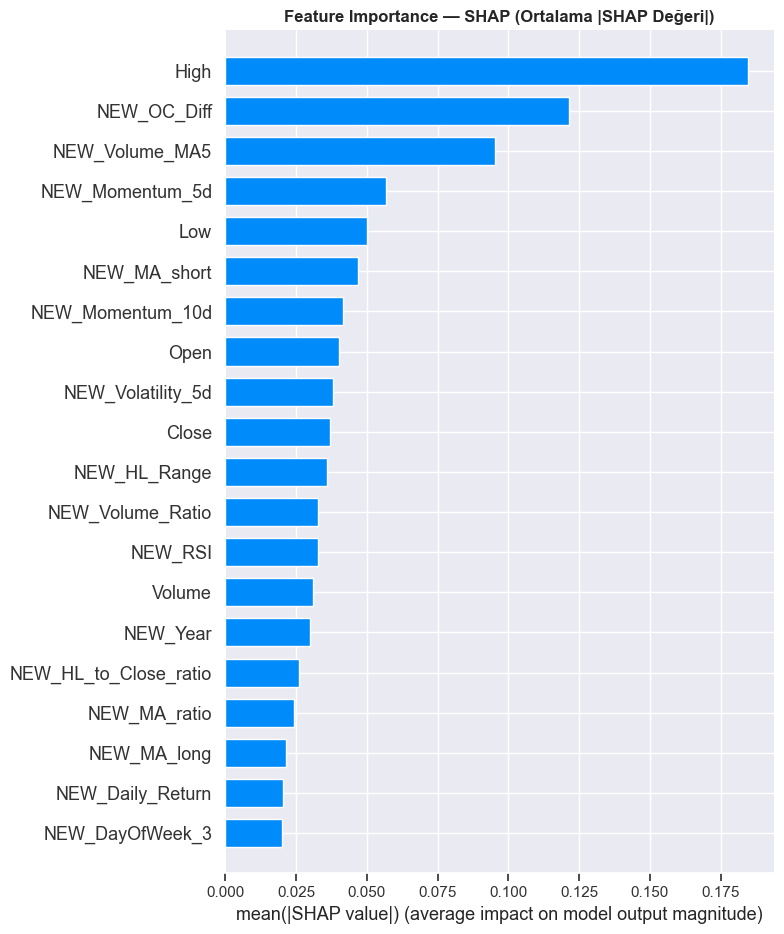

In [44]:
# SHAP Summary Plot — hangi feature modeli ne kadar etkiliyor?
plt.figure(figsize=(10, 8))
shap.summary_plot(sv, X_sample, plot_type="bar", show=False)
plt.title("Feature Importance — SHAP (Ortalama |SHAP Değeri|)", fontweight="bold")
plt.tight_layout()
plt.show()


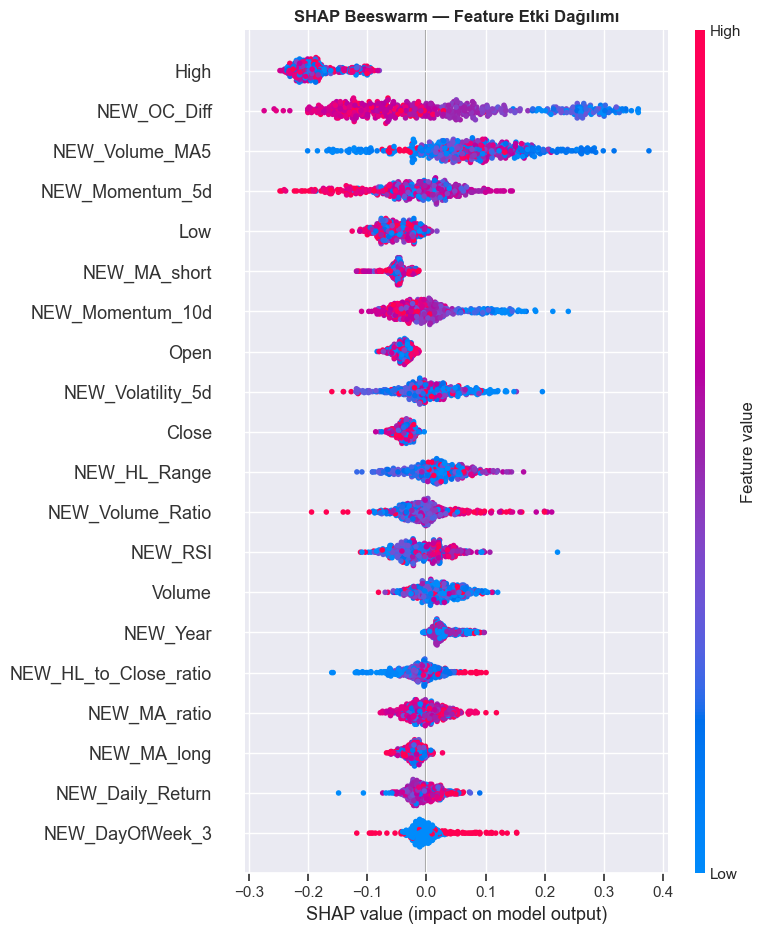

In [45]:
# SHAP Beeswarm — hem önem hem yön bilgisi
plt.figure(figsize=(10, 8))
shap.summary_plot(sv, X_sample, show=False)
plt.title("SHAP Beeswarm — Feature Etki Dağılımı", fontweight="bold")
plt.tight_layout()
plt.show()

# Kırmızı = yüksek feature değeri, Mavi = düşük feature değeri
# Sağ = model bu özellik nedeniyle 'Arttı' tahmin etti


## 15. Proje Özeti ve Sonuçlar

In [46]:
print("=" * 60)
print("PROJE ÖZETI")
print("=" * 60)
print()
print(f"Veri: MSFT Daily OHLCV (1986-2024)")
print(f"Problem: Binary Classification (fiyat yönü tahmini)")
print(f"Toplam örnek: {len(df)}")
print(f"Feature sayısı (final): {X_train_scaled.shape[1]}")
print()
print("Model Karşılaştırması (Test ROC-AUC):")
print(results_df[["Model", "Test_ROC", "Test_F1"]].to_string(index=False))
print()
print("Tuned LightGBM (best model):")
print(f"  ROC-AUC  : {roc_auc_score(y_test, y_prob_best):.4f}")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"  F1       : {f1_score(y_test, y_pred_best):.4f}")
print()
print("NOT: Hisse senedi fiyatı tahmin etmek gerçekten zor.")
print("     ~0.55-0.58 ROC-AUC bile finansal ML'de kabul edilebilir.")
print("     Bu proje bir finansal tavsiye değil, öğrenme amaçlıdır!")


PROJE ÖZETI

Veri: MSFT Daily OHLCV (1986-2024)
Problem: Binary Classification (fiyat yönü tahmini)
Toplam örnek: 9688
Feature sayısı (final): 45

Model Karşılaştırması (Test ROC-AUC):
              Model  Test_ROC  Test_F1
           LightGBM  0.536197 0.409786
Logistic Regression  0.535243 0.294203
      Random Forest  0.532970 0.122098
           CatBoost  0.532960 0.417529
  Gradient Boosting  0.520566 0.435281
            XGBoost  0.520160 0.307158
   Dummy (Baseline)  0.500000 0.000000

Tuned LightGBM (best model):
  ROC-AUC  : 0.5405
  Accuracy : 0.5098
  F1       : 0.3957

NOT: Hisse senedi fiyatı tahmin etmek gerçekten zor.
     ~0.55-0.58 ROC-AUC bile finansal ML'de kabul edilebilir.
     Bu proje bir finansal tavsiye değil, öğrenme amaçlıdır!
